# Cost saving opportunity for HCP

This jupyter notebook uses the following HCE table to get CPU utilization and AWS cost dataset:
* uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
* uip_iceberg.infra_analytics.hyperforce_aws_cost_allocated_view

Please read [this decision record](https://salesforce.quip.com/9u7CATaZNDz8) to understand how to calculate the utilization and cost.


If P95 CPU Utilization < 35%:

$$
  Saving Opportunity = \left(HCE Pod Cost ($) * 0.5\right) \times \left( 1-\frac{P95 CPU Utilization}{35} \right)
$$



## Initialization

In [66]:
%reload_ext autoreload
%autoreload 2

import os
import sys
module_path = os.path.abspath(os.path.join('../'))
sys.path.insert(0, module_path)

from huron.pod import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
from datetime import datetime, timedelta
from collections import Counter

# If you want to print out SQL Query, set log level to logging.INFO.
logging.getLogger().setLevel(logging.INFO)

## Connect to UIP

### Option 1: UIP Notebook (Recommended)

Create Notebook by following [User Guide - UIP Notebook 2.0](https://confluence.internal.salesforce.com/display/UIP/User+Guide+-+UIP+Notebook+2.0#UserGuideUIPNotebook2.0-Prerequisites).

### Option 2: Local environment

1. Download [cacert.pem](https://git.soma.salesforce.com/Infrastructure-Security/puppet_pki_agent/blob/master/files/prod_ca/cacerts.pem) and save it as `.cacert.pem`
2. Copy the trino access code from [Salesforce trino authenticator](https://bdmpresto-access-server.sfproxy.uip.aws-esvc1-useast2.aws.sfdc.cl/)
3. Update the [.secrets.json](./.secrets.json) file

```json
{
    "username": "your_user_name",
    "access_code": "trino_access_code"
}
```

In [67]:
conn = None

try:
    from huron import connect_huron
    conn = connect_huron()
except:
    from uip_client.trino import TrinoConnection

    conn = TrinoConnection(
        catalog='huron-metrics',
        schema='metrics_hourly'
    )

INFO:root:Using Certificate Authentication...


## 2. Configure environment

By default, this script queries the metrics for `stage`, `esvc`, and `prod` environments. If you want to change the environment, please edit `ENV_TYPE` below.

In [68]:
ENV_TYPE = ['dev', 'test', 'perf','prod', 'stage', 'esvc']

TIMERANGE_FROM = '2025-07-01 00:00:00'
TIMERANGE_TO = '2025-07-31 00:00:00'

# Configure maximum rows for displaying dataframes
pd.options.display.max_rows = 100
# Configure maximum cols for displaying dataframes
pd.options.display.max_columns = 50
pd.options.display.float_format = '{:.3f}'.format

NAMESPACES = ["sam-system", "kube-system"]

# Set default custom filter. filter only sam cluster.
CUSTOM_FILTERS = "k8s_cluster like 'sam-%'"
# e.g. filter out coredns pod
#CUSTOM_FILTERS = "k8s_cluster like 'sam-%' AND k8s_pod_name like 'coredns%'"

In [69]:
# The following template gets the maximum request cpu and memory from kube-stat-metric
SQL_RESOURCE_TEMPLATE = """
with dedupe as (
  SELECT
      _time,
      scope,
      k8s_cluster,
      k8s_namespace,
      k8s_pod_name,
      k8s_container_name,
      element_at(tags,'resource') AS metric_type,
      MAX(max_value) AS value
  FROM huron_iceberg.metrics.metrics_hourly
  WHERE
    scope like '%(scope)s'
    AND metric = 'kube_pod_container_resource_requests'
    AND element_at(tags, 'resource') IN ('cpu', 'memory')
    AND element_at(tags, 'environment_type') in (%(envs)s)
    AND _time between TIMESTAMP '%(timerange_from)s' and TIMESTAMP '%(timerange_to)s'
    %(filters)s
  GROUP BY
      1,2,3,4,5,6,7
), sum_agg as (
  SELECT
      _time,
      scope, 
      k8s_cluster,
      k8s_namespace,
      k8s_pod_name,
    SUM(CASE
         WHEN metric_type = 'cpu'
         THEN value
         ELSE NULL
    END) as pod_request_cpu,
    SUM(CASE
         WHEN metric_type = 'memory'
         THEN value
         ELSE NULL
    END) as pod_request_mem
    FROM dedupe
  GROUP BY 1,2,3,4,5
)
SELECT
  format_datetime(_time, 'yyyyMMdd') as date_key,
  scope, 
  k8s_cluster,
  k8s_namespace,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  MAX(ROUND(pod_request_cpu, 5)) as request_cpu,
  MAX(pod_request_mem) as request_memory
FROM sum_agg
GROUP BY 1,2,3,4,5
ORDER BY date_key, scope, k8s_cluster, k8s_pod_name asc

"""

df_resource_spec = get_pod_with_resource_quota(conn, SQL_RESOURCE_TEMPLATE, TIMERANGE_FROM, TIMERANGE_TO, ENV_TYPE, HOURLY_METRIC_TABLE, NAMESPACES, CUSTOM_FILTERS)
df_resource_spec['resource_type'] = df_resource_spec.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[0], axis=1)
df_resource_spec['resource_name'] = df_resource_spec.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[1], axis=1)
df_resource_spec['deployment_name'] = df_resource_spec.apply(extract_deployment, axis=1)
df_resource_spec

INFO:root:
with dedupe as (
  SELECT
      _time,
      scope,
      k8s_cluster,
      k8s_namespace,
      k8s_pod_name,
      k8s_container_name,
      element_at(tags,'resource') AS metric_type,
      MAX(max_value) AS value
  FROM huron_iceberg.metrics.metrics_hourly
  WHERE
    scope like 'kube-state-metrics.aws.%'
    AND metric = 'kube_pod_container_resource_requests'
    AND element_at(tags, 'resource') IN ('cpu', 'memory')
    AND element_at(tags, 'environment_type') in ('dev', 'test', 'perf', 'prod', 'stage', 'esvc')
    AND _time between TIMESTAMP '2025-07-01 00:00:00' and TIMESTAMP '2025-07-31 00:00:00'
    AND k8s_namespace in ('sam-system', 'kube-system') AND k8s_cluster like 'sam-%'
  GROUP BY
      1,2,3,4,5,6,7
), sum_agg as (
  SELECT
      _time,
      scope, 
      k8s_cluster,
      k8s_namespace,
      k8s_pod_name,
    SUM(CASE
         WHEN metric_type = 'cpu'
         THEN value
         ELSE NULL
    END) as pod_request_cpu,
    SUM(CASE
         WHEN metric_

,date_key,scope,k8s_cluster,k8s_namespace,pod_group,k8s_pod_name,request_cpu,request_memory,resource_type,resource_name,deployment_name
0,20250701,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,aws-load-balancer-controller-59654bb7b8,aws-load-balancer-controller-59654bb7b8-nwlgc,0.049,764046746.000,replicaset,aws-load-balancer-controller-59654bb7b8,aws-load-balancer-controller
1,20250701,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,aws-node,aws-node-tnx5h,0.025,67108864.000,daemonset,aws-node,aws-node
2,20250701,aws.aws-dev2-uswest2.apiq,sam-processing1,sam-system,cloudwatch-logexport-598816239137,cloudwatch-logexport-598816239137-0,0.220,786432000.000,statefulset,cloudwatch-logexport,cloudwatch-logexport
3,20250701,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,coredns-8cd545679,coredns-8cd545679-4pgx2,0.100,2147483648.000,replicaset,coredns-8cd545679,coredns
4,20250701,aws.aws-dev2-uswest2.apiq,sam-processing1,sam-system,dataplane-test-ds,dataplane-test-ds-stgt6,0.080,492830720.000,daemonset,dataplane-test-ds,dataplane-test-ds
...,...,...,...,...,...,...,...,...,...,...,...
902686,20250731,aws.test1-uswest2.unified-engagement,sam-restricted1,kube-system,snapshot-controller-5bf8c457bd,snapshot-controller-5bf8c457bd-l89rk,0.200,536870912.000,replicaset,snapshot-controller-5bf8c457bd,snapshot-controller
902687,20250731,aws.test1-uswest2.unified-engagement,sam-restricted1,kube-system,snapshot-validation-6cf565dbc,snapshot-validation-6cf565dbc-7cxfg,0.200,536870912.000,replicaset,snapshot-validation-6cf565dbc,snapshot-validation
902688,20250731,aws.test1-uswest2.unified-engagement,sam-restricted1,kube-system,vertical-pod-autoscaler-admission-controller-5...,vertical-pod-autoscaler-admission-controller-5...,0.250,268435456.000,replicaset,vertical-pod-autoscaler-admission-controller-5...,vertical-pod-autoscaler-admission-controller
902689,20250731,aws.test1-uswest2.unified-engagement,sam-restricted1,kube-system,vertical-pod-autoscaler-recommender-6cc6649dd8,vertical-pod-autoscaler-recommender-6cc6649dd8...,0.011,144645763.000,replicaset,vertical-pod-autoscaler-recommender-6cc6649dd8,vertical-pod-autoscaler-recommender


In [70]:
# grouping by cluster
df_resource_quota_per_deploy = df_resource_spec[['date_key','scope','k8s_cluster','k8s_namespace','deployment_name', 'request_cpu', 'request_memory']].groupby(by=['date_key','scope','k8s_cluster','k8s_namespace','deployment_name', 'request_cpu', 'request_memory']).any().reset_index()
df_resource_quota_per_deploy['date_key'] = pd.to_numeric(df_resource_quota_per_deploy['date_key'])
df_resource_quota_per_deploy

,date_key,scope,k8s_cluster,k8s_namespace,deployment_name,request_cpu,request_memory
0,20250701,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,aws-load-balancer-controller,0.049,764046746.000
1,20250701,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,aws-node,0.025,67108864.000
2,20250701,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,coredns,0.100,2147483648.000
3,20250701,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,ebs-csi-controller,0.077,217673496.000
4,20250701,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,ebs-csi-node,0.300,805306368.000
...,...,...,...,...,...,...,...
859581,20250731,aws.test1-uswest2.unified-engagement,sam-restricted1,sam-system,host-path-permission-setter,0.001,10485760.000
859582,20250731,aws.test1-uswest2.unified-engagement,sam-restricted1,sam-system,komputegroup,0.200,268435456.000
859583,20250731,aws.test1-uswest2.unified-engagement,sam-restricted1,sam-system,kube-hpa-generator,0.570,1474297856.000
859584,20250731,aws.test1-uswest2.unified-engagement,sam-restricted1,sam-system,orphaned-volumes-pruner,0.200,524288000.000


In [71]:
# Calculate 
sql_cpu_util = """
WITH util_data AS (
  SELECT * FROM uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
  WHERE
    date_key between %(timerange_from)s and %(timerange_to)s
    AND level = 'pod'
    AND metric_name = 'cpu_req_util'
    AND aws_service = 'EC2 - Compute'
    AND k8s_pod_name is not NULL
    AND environment_type IN (%(envs)s)
    %(filters)s
)
SELECT
  date_key,
  concat('aws.', falcon_instance, '.', functional_domain) as scope,
  functional_domain,
  falcon_instance,
  environment_type,
  k8s_namespace,
  k8s_cluster,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  APPROX_PERCENTILE(util, value_count, 0.99) as p99_cpu,
  APPROX_PERCENTILE(util, value_count, 0.95) as p95_cpu
FROM util_data, UNNEST(value_counts)  AS ckv (util, value_count)
GROUP BY 1,2,3,4,5,6,7,8
ORDER BY date_key asc
"""

df_hce_cpu_util = query_aws_pod_unit_cost(conn, sql_cpu_util, TIMERANGE_FROM, TIMERANGE_TO, ENV_TYPE, NAMESPACES, CUSTOM_FILTERS)
df_hce_cpu_util['resource_type'] = df_hce_cpu_util.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[0], axis=1)
df_hce_cpu_util['resource_name'] = df_hce_cpu_util.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[1], axis=1)
df_hce_cpu_util['deployment_name'] = df_hce_cpu_util.apply(extract_deployment, axis=1)
df_hce_cpu_util.drop('k8s_pod_name', axis=1, inplace=True)
df_hce_cpu_util

INFO:root:
WITH util_data AS (
  SELECT * FROM uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
  WHERE
    date_key between 20250701 and 20250731
    AND level = 'pod'
    AND metric_name = 'cpu_req_util'
    AND aws_service = 'EC2 - Compute'
    AND k8s_pod_name is not NULL
    AND environment_type IN ('dev', 'test', 'perf', 'prod', 'stage', 'esvc')
    AND k8s_namespace in ('sam-system', 'kube-system') AND k8s_cluster like 'sam-%'
)
SELECT
  date_key,
  concat('aws.', falcon_instance, '.', functional_domain) as scope,
  functional_domain,
  falcon_instance,
  environment_type,
  k8s_namespace,
  k8s_cluster,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  APPROX_PERCENTILE(util, value_count, 0.99) as p99_cpu,
  APPROX_PERCENTILE(util, value_count, 0.95) as p95_cpu
FROM util_data, UNNEST(value_counts)  AS ckv (util, value_count)
GROUP BY 1,2,3,4,5,6,7,8
ORDER BY date_key asc



,date_key,scope,functional_domain,falcon_instance,environment_type,k8s_namespace,k8s_cluster,pod_group,p99_cpu,p95_cpu,resource_type,resource_name,deployment_name
0,20250701,aws.aws-prod4-apsoutheast2.tableau,tableau,aws-prod4-apsoutheast2,prod,kube-system,sam-processing1,kube-proxy,13.113,7.670,daemonset,kube-proxy,kube-proxy
1,20250701,aws.dev1-uswest2.core002,core002,dev1-uswest2,dev,kube-system,sam-processing-sc1,identity-controller-587fc9846c,317.749,308.701,replicaset,identity-controller-587fc9846c,identity-controller
2,20250701,aws.aws-prod19-eusouth1.core1,core1,aws-prod19-eusouth1,prod,kube-system,sam-restricted5,aws-node,26.000,24.959,daemonset,aws-node,aws-node
3,20250701,aws.test1-uswest2.fieldservice,fieldservice,test1-uswest2,test,kube-system,sam-processing1,snapshot-controller-755b64586b,0.000,0.000,replicaset,snapshot-controller-755b64586b,snapshot-controller
4,20250701,aws.aws-prod1-useast1.einstein2,einstein2,aws-prod1-useast1,prod,sam-system,sam-restricted1,host-path-permission-setter,4.000,4.000,daemonset,host-path-permission-setter,host-path-permission-setter
...,...,...,...,...,...,...,...,...,...,...,...,...,...
773194,20250731,aws.aws-prod24-apsouth2.foundation,foundation,aws-prod24-apsouth2,prod,kube-system,sam-control1,snapshot-controller-9bff468bd,0.000,0.000,replicaset,snapshot-controller-9bff468bd,snapshot-controller
773195,20250731,aws.aws-dev4-uswest2.foundation,foundation,aws-dev4-uswest2,dev,kube-system,sam-logging-monitoring1,kube-dns-autoscaler-576955595,1.982,1.891,replicaset,kube-dns-autoscaler-576955595,kube-dns-autoscaler
773196,20250731,aws.fdev1-uswest2.foundation,foundation,fdev1-uswest2,dev,kube-system,sam-test-seccomp,identity-controller-fit-test-849dd79777,45.208,44.474,replicaset,identity-controller-fit-test-849dd79777,identity-controller-fit-test
773197,20250731,aws.aws-prod3-eucentral1.core1,core1,aws-prod3-eucentral1,prod,sam-system,sam-restricted5,fkp-watchdog-7c698b6f9d,6.969,5.889,replicaset,fkp-watchdog-7c698b6f9d,fkp-watchdog


In [72]:
# Calculate 
sql_mem_util = """
WITH util_data AS (
  SELECT * FROM uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
  WHERE
    date_key between %(timerange_from)s and %(timerange_to)s
    AND level = 'pod'
    AND metric_name = 'memory_req_util'
    AND aws_service = 'EC2 - Compute'
    AND k8s_pod_name is not NULL
    AND environment_type IN (%(envs)s)
    %(filters)s
)
SELECT
  date_key,
  concat('aws.', falcon_instance, '.', functional_domain) as scope,
  functional_domain,
  falcon_instance,
  environment_type,
  k8s_namespace,
  k8s_cluster,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  APPROX_PERCENTILE(util, value_count, 0.99) as p99_mem,
  APPROX_PERCENTILE(util, value_count, 0.95) as p95_mem
FROM util_data, UNNEST(value_counts)  AS ckv (util, value_count)
GROUP BY 1,2,3,4,5,6,7,8
ORDER BY date_key asc
"""

df_hce_mem_util = query_aws_pod_unit_cost(conn, sql_mem_util, TIMERANGE_FROM, TIMERANGE_TO, ENV_TYPE, NAMESPACES, CUSTOM_FILTERS)
df_hce_mem_util['resource_type'] = df_hce_mem_util.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[0], axis=1)
df_hce_mem_util['resource_name'] = df_hce_mem_util.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[1], axis=1)
df_hce_mem_util['deployment_name'] = df_hce_mem_util.apply(extract_deployment, axis=1)
df_hce_mem_util.drop('k8s_pod_name', axis=1, inplace=True)
df_hce_mem_util

INFO:root:
WITH util_data AS (
  SELECT * FROM uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
  WHERE
    date_key between 20250701 and 20250731
    AND level = 'pod'
    AND metric_name = 'memory_req_util'
    AND aws_service = 'EC2 - Compute'
    AND k8s_pod_name is not NULL
    AND environment_type IN ('dev', 'test', 'perf', 'prod', 'stage', 'esvc')
    AND k8s_namespace in ('sam-system', 'kube-system') AND k8s_cluster like 'sam-%'
)
SELECT
  date_key,
  concat('aws.', falcon_instance, '.', functional_domain) as scope,
  functional_domain,
  falcon_instance,
  environment_type,
  k8s_namespace,
  k8s_cluster,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  APPROX_PERCENTILE(util, value_count, 0.99) as p99_mem,
  APPROX_PERCENTILE(util, value_count, 0.95) as p95_mem
FROM util_data, UNNEST(value_counts)  AS ckv (util, value_count)
GROUP BY 1,2,3,4,5,6,7,8
ORDER BY date_key asc



,date_key,scope,functional_domain,falcon_instance,environment_type,k8s_namespace,k8s_cluster,pod_group,p99_mem,p95_mem,resource_type,resource_name,deployment_name
0,20250701,aws.perf1-useast2.unified-engagement1,unified-engagement1,perf1-useast2,test,kube-system,sam-processing1,identity-controller-cred-refresher-86f677845,22.000,22.000,replicaset,identity-controller-cred-refresher-86f677845,identity-controller-cred-refresher
1,20250701,aws.aws-prod24-apsouth2.uengage1,uengage1,aws-prod24-apsouth2,prod,kube-system,sam-processing1,kube-dns-autoscaler-5584b8b954,5.000,5.000,replicaset,kube-dns-autoscaler-5584b8b954,kube-dns-autoscaler
2,20250701,aws.fdev1-uswest2.foundation,foundation,fdev1-uswest2,dev,kube-system,sam-test-vault-webhook,vertical-pod-autoscaler-updater-5b9f6f475,79.853,73.679,replicaset,vertical-pod-autoscaler-updater-5b9f6f475,vertical-pod-autoscaler-updater
3,20250701,aws.aws-prod10-apsoutheast1.edge,edge,aws-prod10-apsoutheast1,prod,kube-system,sam-processing1,identity-controller-fc8cc5445,32.000,31.919,replicaset,identity-controller-fc8cc5445,identity-controller
4,20250701,aws.aws-prod9-apnortheast1.core1,core1,aws-prod9-apnortheast1,prod,kube-system,sam-restricted2,kube-dns-autoscaler-6b5f4cd98c,8.000,8.000,replicaset,kube-dns-autoscaler-6b5f4cd98c,kube-dns-autoscaler
...,...,...,...,...,...,...,...,...,...,...,...,...,...
809836,20250731,aws.dev1-uswest2.buildndeliver,buildndeliver,dev1-uswest2,dev,sam-system,sam-processing1,dataplane-test-ds,19.000,18.171,daemonset,dataplane-test-ds,dataplane-test-ds
809837,20250731,aws.aws-prod14-apnortheast2.seas,seas,aws-prod14-apnortheast2,prod,kube-system,sam-processing1,identity-controller-cred-refresher-6d7f87dd87,21.000,21.000,replicaset,identity-controller-cred-refresher-6d7f87dd87,identity-controller-cred-refresher
809838,20250731,aws.aws-prod16-eunorth1.security,security,aws-prod16-eunorth1,prod,kube-system,sam-mgmt-truth1,coredns-7c77d455c7,1.000,1.000,replicaset,coredns-7c77d455c7,coredns
809839,20250731,aws.aws-giastage1-usgoveast1.core2,core2,aws-giastage1-usgoveast1,stage,sam-system,sam-restricted3,dataplane-test-ds,17.000,16.000,daemonset,dataplane-test-ds,dataplane-test-ds


In [73]:
sql_cost = """
  SELECT
    date_key,
    concat('aws.', falcon_instance, '.', functional_domain) as scope,
    falcon_instance,
    functional_domain,
    environment_type,
    allocated_service,
    aws_eks_cluster_name as k8s_cluster,
    k8s_namespace,
    substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
    arbitrary(k8s_pod_name) as k8s_pod_name,
    sum(total_cost) as ec2_cost
  FROM uip_iceberg.infra_analytics.hyperforce_aws_cost_allocated_view
  WHERE
    date_key between %(timerange_from)s and %(timerange_to)s
    AND aws_service = 'EC2 - Compute'
    AND k8s_namespace is not NULL AND k8s_container_name is not NULL AND k8s_pod_name is not NULL
    AND environment_type IN (%(envs)s)
    %(filters)s
  GROUP BY
    1,2,3,4,5,6,7,8,9
  ORDER BY date_key
"""

df_cost = query_aws_pod_unit_cost(conn, sql_cost, TIMERANGE_FROM, TIMERANGE_TO, ENV_TYPE, NAMESPACES, CUSTOM_FILTERS)
# The following code parses k8s_pod_name to identify the resource type such as replicaset, statefulset, daemonset, and unknown.
df_cost['resource_type'] = df_cost.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[0], axis=1)
df_cost['resource_name'] = df_cost.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[1], axis=1)

# This code extracts deployment type name if resource_type is replicaset.
df_cost['deployment_name'] = df_cost.apply(extract_deployment, axis=1)
df_cost.drop('k8s_pod_name', axis=1, inplace=True)
df_cost


INFO:root:
  SELECT
    date_key,
    concat('aws.', falcon_instance, '.', functional_domain) as scope,
    falcon_instance,
    functional_domain,
    environment_type,
    allocated_service,
    aws_eks_cluster_name as k8s_cluster,
    k8s_namespace,
    substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
    arbitrary(k8s_pod_name) as k8s_pod_name,
    sum(total_cost) as ec2_cost
  FROM uip_iceberg.infra_analytics.hyperforce_aws_cost_allocated_view
  WHERE
    date_key between 20250701 and 20250731
    AND aws_service = 'EC2 - Compute'
    AND k8s_namespace is not NULL AND k8s_container_name is not NULL AND k8s_pod_name is not NULL
    AND environment_type IN ('dev', 'test', 'perf', 'prod', 'stage', 'esvc')
    AND k8s_namespace in ('sam-system', 'kube-system') AND aws_eks_cluster_name like 'sam-%'
  GROUP BY
    1,2,3,4,5,6,7,8,9
  ORDER BY date_key



,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name
0,20250701,aws.dev1-uswest2.foundation,dev1-uswest2,foundation,dev,sam,sam-processing1,kube-system,kube-proxy,1.082,daemonset,kube-proxy,kube-proxy
1,20250701,aws.fdev1-uswest2.foundation,fdev1-uswest2,foundation,dev,sam,sam-processing5,sam-system,dataplane-test-ds,0.216,daemonset,dataplane-test-ds,dataplane-test-ds
2,20250701,aws.aws-prod9-apnortheast1.foundation,aws-prod9-apnortheast1,foundation,prod,sam,sam-log-mon1,kube-system,coredns-78844f8fcf,3.427,replicaset,coredns-78844f8fcf,coredns
3,20250701,aws.perf2-uswest2.foundation,perf2-uswest2,foundation,test,sam,sam-processing4,sam-system,htp-scale-test827-66b854766d,0.173,replicaset,htp-scale-test827-66b854766d,htp-scale-test827
4,20250701,aws.aws-prod21-useast2.core1,aws-prod21-useast2,core1,prod,sam,sam-restricted6,kube-system,aws-node,1.124,daemonset,aws-node,aws-node
...,...,...,...,...,...,...,...,...,...,...,...,...,...
841257,20250731,aws.perf1-useast2.core1,perf1-useast2,core1,test,sam,sam-processing-sc1,kube-system,kube-proxy,0.997,daemonset,kube-proxy,kube-proxy
841258,20250731,aws.aws-prod5-uswest2.tableau,aws-prod5-uswest2,tableau,prod,sam,sam-processing8,sam-system,dataplane-test-ds,6.017,daemonset,dataplane-test-ds,dataplane-test-ds
841259,20250731,aws.aws-prod1-useast1.core1,aws-prod1-useast1,core1,prod,sam,sam-restricted2,sam-system,host-path-permission-setter,0.093,daemonset,host-path-permission-setter,host-path-permission-setter
841260,20250731,aws.aws-prod24-apsouth2.einstein,aws-prod24-apsouth2,einstein,prod,sam,sam-restricted1,kube-system,kube-dns-autoscaler-d64894dd4,0.010,replicaset,kube-dns-autoscaler-d64894dd4,kube-dns-autoscaler


In [74]:
df_cost[['date_key', 'ec2_cost']].groupby(by='date_key').sum()
df_cost.to_csv("cpu_cost_aug01_aug31_all_env.csv")

In [75]:
df_cost[df_cost['pod_group'].str.startswith('kube-node-recycler')] 

,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name


In [76]:
df_util_merged = df_hce_cpu_util.merge(df_hce_mem_util, how='left').merge(df_resource_quota_per_deploy, how='left')
withcost_hce = df_cost.merge(df_util_merged, how='left').sort_values(by=['date_key', 'scope', 'k8s_cluster']).reset_index(drop=True)
withcost_hce
withcost_hce.to_csv("sam_cost_aug01_aug31_all_env.csv")

In [77]:
withcost_hce[withcost_hce['deployment_name'] == 'coredns']

,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name,p99_cpu,p95_cpu,p99_mem,p95_mem,request_cpu,request_memory
10,20250701,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,kube-system,coredns-8cd545679,1.290,replicaset,coredns-8cd545679,coredns,130.598,115.048,3.000,3.000,0.100,2147483648.000
97,20250701,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-restricted1,kube-system,coredns-7d85bccf8,0.913,replicaset,coredns-7d85bccf8,coredns,34.000,32.000,1.000,1.000,0.100,2147483648.000
111,20250701,aws.aws-dev2-uswest2.ast,aws-dev2-uswest2,ast,dev,sam,sam-processing1,kube-system,coredns-6fc8fdd94,1.245,replicaset,coredns-6fc8fdd94,coredns,257.146,227.334,3.000,3.000,0.100,2147483648.000
153,20250701,aws.aws-dev2-uswest2.cdp1,aws-dev2-uswest2,cdp1,dev,sam,sam-processing1,kube-system,coredns-79b88c5c86,0.686,replicaset,coredns-79b88c5c86,coredns,42.000,40.000,2.000,2.000,0.100,2147483648.000
177,20250701,aws.aws-dev2-uswest2.controltelemetry,aws-dev2-uswest2,controltelemetry,dev,sam,sam-processing1,kube-system,coredns-6d768cb945,0.562,replicaset,coredns-6d768cb945,coredns,229.987,219.095,2.000,2.000,0.100,2147483648.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845656,20250731,aws.test1-uswest2.security,test1-uswest2,security,test,sam,sam-mgmt-truth1,kube-system,coredns-5f4bb6f94b,0.614,replicaset,coredns-5f4bb6f94b,coredns,169.026,161.513,2.000,2.000,0.100,2147483648.000
845685,20250731,aws.test1-uswest2.tableau,test1-uswest2,tableau,test,sam,sam-processing1,kube-system,coredns-7bf6f7c476,1.559,replicaset,coredns-7bf6f7c476,coredns,233.909,219.358,3.000,3.000,0.100,2147483648.000
845736,20250731,aws.test1-uswest2.tableau,test1-uswest2,tableau,test,sam,sam-processing2,kube-system,coredns-cd687658,0.487,replicaset,coredns-cd687658,coredns,117.000,110.656,2.000,2.000,0.100,2147483648.000
845762,20250731,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-processing1,kube-system,coredns-5d96945b77,1.194,replicaset,coredns-5d96945b77,coredns,581.877,542.821,3.000,2.897,0.100,2147483648.000


In [78]:
# Use the same calculation - https://confluence.internal.salesforce.com/display/DATASCI/Cost+-+Frequently+Asked+Questions#CostFrequentlyAskedQuestions-Campaign:LowP95CPUUtilization

def calculate_saving_cost(row):
    if row['p95_cpu'] >= 35.0:
        return 0.0
    return (row['ec2_cost'] * 0.50) * (1.0-(row['p95_cpu']/35.0))

withcost_hce['saving_opportunity'] = withcost_hce.apply(calculate_saving_cost, axis=1)
withcost_hce
withcost_hce.to_csv("savingsopportunity_aug01_aug31_all_env.csv")

In [79]:
# filter out unncessary deployments e.g. fit-validator, moncfg
df_result = withcost_hce[(~withcost_hce['deployment_name'].str.startswith('fit-karpenter')) & (~withcost_hce['deployment_name'].str.startswith('fit-validator')) & (~withcost_hce['deployment_name'].str.startswith('moncfg-'))]

In [80]:
df_result

,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name,p99_cpu,p95_cpu,p99_mem,p95_mem,request_cpu,request_memory,saving_opportunity
2,20250701,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,sam-system,kube-hpa-generator-6f49c5df6b,0.110,replicaset,kube-hpa-generator-6f49c5df6b,kube-hpa-generator,4.000,1.997,10.000,10.000,0.570,1474297856.000,0.052
7,20250701,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,kube-system,vertical-pod-autoscaler-updater-5c594fb96d,0.160,replicaset,vertical-pod-autoscaler-updater-5c594fb96d,vertical-pod-autoscaler-updater,213.750,146.100,88.778,81.863,0.035,1555165137.000,0.000
9,20250701,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,sam-system,fkp-watchdog-5dc9ccdc8c,0.224,replicaset,fkp-watchdog-5dc9ccdc8c,fkp-watchdog,76.000,70.587,60.580,18.814,0.570,3646947328.000,0.000
10,20250701,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,kube-system,coredns-8cd545679,1.290,replicaset,coredns-8cd545679,coredns,130.598,115.048,3.000,3.000,0.100,2147483648.000,0.000
11,20250701,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,sam-system,sam-synth-test-555d8654b5,0.024,replicaset,sam-synth-test-555d8654b5,sam-synth-test,12.000,4.000,15.000,14.000,0.080,492830720.000,0.010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845800,20250731,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,identity-controller-refresher,sam-restricted1,kube-system,identity-controller-cred-refresher-db6f66f8,0.011,replicaset,identity-controller-cred-refresher-db6f66f8,identity-controller-cred-refresher,3.376,2.930,24.663,22.958,0.030,209715200.000,0.005
845801,20250731,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-restricted1,kube-system,aws-node,0.267,daemonset,aws-node,aws-node,14.000,13.000,213.735,191.509,0.025,67108864.000,0.084
845802,20250731,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-restricted1,sam-system,dataplane-test-ds,0.694,daemonset,dataplane-test-ds,dataplane-test-ds,4.000,3.934,25.318,21.992,0.080,492830720.000,0.308
845803,20250731,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,komputegroup,sam-restricted1,sam-system,komputegroup-76d4fc4c97,0.000,replicaset,komputegroup-76d4fc4c97,komputegroup,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [81]:
withcost_hce[['deployment_name', 'ec2_cost', 'p95_cpu','p95_mem']].groupby('deployment_name').agg({'ec2_cost': np.sum, 'p95_cpu': np.mean, 'p95_mem':np.mean})

/tmp/ipykernel_832/3295590337.py:1: FutureWarning: The provided callable <function sum at 0x7f2cf80da980> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  withcost_hce[['deployment_name', 'ec2_cost', 'p95_cpu','p95_mem']].groupby('deployment_name').agg({'ec2_cost': np.sum, 'p95_cpu': np.mean, 'p95_mem':np.mean})
/tmp/ipykernel_832/3295590337.py:1: FutureWarning: The provided callable <function mean at 0x7f2cf80dba60> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  withcost_hce[['deployment_name', 'ec2_cost', 'p95_cpu','p95_mem']].groupby('deployment_name').agg({'ec2_cost': np.sum, 'p95_cpu': np.mean, 'p95_mem':np.mean})


,ec2_cost,p95_cpu,p95_mem
deployment_name,,,
argo-utility-pod,0.064,1.000,14.000
aws-load-balancer-controller,97235.321,14.802,14.899
aws-node,19577.269,16.407,213.814
base-deployment1,0.034,NaN,NaN
base-deployment10,0.034,NaN,NaN
...,...,...,...
volume-expansion-test93,0.000,NaN,NaN
volume-expansion-test96,0.000,0.000,6.000
volume-expansion-test97,0.000,0.000,5.000


In [82]:
df_result.to_csv('aug01_aug31_all_env_monthly_cost_utilization.csv', index=False)

In [83]:
only_coredns= withcost_hce[withcost_hce['deployment_name'] == 'coredns'][['date_key','deployment_name', 'ec2_cost']].groupby(by=['date_key', 'deployment_name']).sum()

In [84]:
only_coredns.to_csv('coredns_daily_aug01_aug31_all_env.csv')

## Generate report

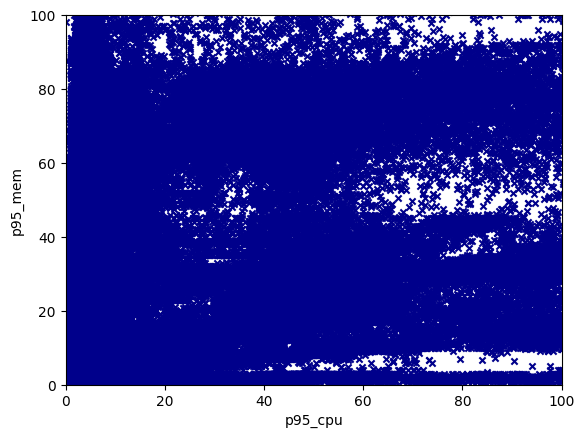

In [85]:
ax1 = df_result.plot.scatter(x='p95_cpu', y='p95_mem', c='DarkBlue', marker="x", xlim=[0, 100], ylim=[0, 100])

In [86]:
df_cost_sum = df_result[['date_key', 'ec2_cost', 'p95_cpu', 'p95_mem']]
df_cost_sum = df_cost_sum[~df_cost_sum['p95_cpu'].isna()]
df_cost_sum = df_cost_sum[~df_cost_sum['p95_mem'].isna()]

df_cost_sum.groupby('date_key').apply(lambda x: np.average(x['p95_cpu'], weights=x['ec2_cost'])).mean()

9.490013098268864

In [87]:
df_cost_sum.groupby('date_key').apply(lambda x: np.average(x['p95_mem'], weights=x['ec2_cost'])).mean()

14.634064364698597

In [88]:
df_utilization_summary = df_result[['resource_type','deployment_name', 'request_cpu', 'request_memory', 'p95_cpu' ,'p95_mem']].groupby(by=['resource_type','deployment_name', 'request_cpu', 'request_memory']).mean().reset_index()
df_utilization_summary.columns = ['resource_type','Deployment Name', 'Request CPU', 'Request Memory', 'Average CPU Utilization (%) at p95 level', 'Average Memory utilization (%) at p95 level']
df_utilization_summary

,resource_type,Deployment Name,Request CPU,Request Memory,Average CPU Utilization (%) at p95 level,Average Memory utilization (%) at p95 level
0,daemonset,aws-node,0.025,67108864.000,15.665,237.339
1,daemonset,aws-node,0.025,268435456.000,19.923,69.476
2,daemonset,dataplane-test-ds,0.030,224395264.000,4.150,19.853
3,daemonset,dataplane-test-ds,0.080,492830720.000,4.388,18.120
4,daemonset,dataplane-test-ds,0.100,650117120.000,4.254,16.729
...,...,...,...,...,...,...
5438,statefulset,volume-expansion-test61,0.050,67108864.000,0.000,6.000
5439,statefulset,volume-expansion-test90,0.050,67108864.000,0.000,6.000
5440,statefulset,volume-expansion-test96,0.050,67108864.000,0.000,6.000
5441,statefulset,volume-expansion-test97,0.050,67108864.000,0.000,5.000


In [89]:
# We want to aggregate daily ec2_cost and saving_opportunity by sum. In order to execute this aggregation,
# 1. Select 'date_key', 'k8s_namespace', 'deployment_name', 'ec2_cost', 'saving_opportunity' columns
# 2. Group by 'date_key', 'k8s_namespace', 'deployment_name' with sum aggregation at deployment level.
# 3. Reset the index

df_dailysaving_by_name = df_result[['date_key',  'resource_type', 'deployment_name', 'ec2_cost', 'saving_opportunity']].groupby(by=['date_key',  'resource_type','deployment_name']).sum().sort_values(by=['date_key','resource_type', 'deployment_name']).reset_index()
df_dailysaving_by_name['yearly_saving'] = df_dailysaving_by_name.apply(lambda x: x['saving_opportunity'] * 365.0, axis=1)
df_dailysaving_by_name.columns = ['Date',  'Resource type', 'Name', 'Daily EC2 cost', 'Daily cost saving opportunity (USD)', 'Yearly saving opportunity estimate (USD, daily saving opportunity * 365)']
df_dailysaving_by_name

,Date,Resource type,Name,Daily EC2 cost,Daily cost saving opportunity (USD),"Yearly saving opportunity estimate (USD, daily saving opportunity * 365)"
0,20250701,daemonset,aws-node,669.531,122.115,44572.065
1,20250701,daemonset,dataplane-test-ds,2571.718,1109.475,404958.336
2,20250701,daemonset,ebs-csi-node,6643.174,3320.016,1211805.868
3,20250701,daemonset,efs-csi-node,2145.310,945.671,345169.779
4,20250701,daemonset,eks-node-monitoring-agent,0.165,0.000,0.000
...,...,...,...,...,...,...
24417,20250731,replicaset,vertical-pod-autoscaler-recommender,139.046,59.834,21839.284
24418,20250731,replicaset,vertical-pod-autoscaler-updater,143.561,59.893,21860.918
24419,20250731,replicaset,vpa-generator,0.024,0.012,4.255
24420,20250731,statefulset,cloudwatch-logexport,186.881,64.082,23390.026


In [90]:
df_daily_sum = df_dailysaving_by_name[['Date', 'Daily EC2 cost', 'Daily cost saving opportunity (USD)']].groupby(by='Date').sum().reset_index()
df_daily_sum[['Daily EC2 cost', 'Daily cost saving opportunity (USD)']].mean()

Daily EC2 cost                        26095.891
Daily cost saving opportunity (USD)   11090.515
dtype: float64

In [91]:
df_dailysaving_total_by_namespace = df_result[['date_key',  'ec2_cost', 'saving_opportunity']].groupby(by=['date_key', ]).sum().reset_index()
df_dailysaving_total_by_namespace.columns = ['Date',  'Total daily EC2 cost (USD)', 'Total daily cost saving opportunity (USD)']
df_dailysaving_total_by_namespace

,Date,Total daily EC2 cost (USD),Total daily cost saving opportunity (USD)
0,20250701,26658.390,11636.965
1,20250702,26797.721,11657.614
2,20250703,26353.897,0.000
3,20250704,26524.574,11599.279
4,20250705,26063.852,11565.497
5,20250706,26256.704,11671.447
6,20250707,27314.925,12069.387
7,20250708,27289.266,12033.783
8,20250709,26543.346,11691.054
9,20250710,26809.121,11767.804


## Export data

In [92]:
# Export dataframe to csv files
df_utilization_summary.to_csv('./hce-costanalysis-utilization-summary-aug01_aug31_all_env.csv', index=False)
df_dailysaving_by_name.to_csv('./hce-costanalysis-cost-saving-aug01_aug31_all_env.csv', index=False)
df_dailysaving_total_by_namespace.to_csv('./hce-costanalysis-total-saving-namespace-aug01_aug31_all_env.csv', index=False)

In [93]:
withcost_hce[withcost_hce['deployment_name'] == 'ebs-csi-controller']

,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name,p99_cpu,p95_cpu,p99_mem,p95_mem,request_cpu,request_memory,saving_opportunity
23,20250701,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,kube-system,ebs-csi-controller-5589696fc9,0.049,replicaset,ebs-csi-controller-5589696fc9,ebs-csi-controller,15.235,13.000,69.834,65.055,0.077,217673496.000,0.016
90,20250701,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-restricted1,kube-system,ebs-csi-controller-6cbcd77845,0.058,replicaset,ebs-csi-controller-6cbcd77845,ebs-csi-controller,9.128,8.000,52.873,52.230,0.077,241731424.000,0.022
128,20250701,aws.aws-dev2-uswest2.ast,aws-dev2-uswest2,ast,dev,sam,sam-processing1,kube-system,ebs-csi-controller-5cfb746bff,0.050,replicaset,ebs-csi-controller-5cfb746bff,ebs-csi-controller,16.163,13.864,65.276,63.407,0.077,230352246.000,0.015
137,20250701,aws.aws-dev2-uswest2.cdp1,aws-dev2-uswest2,cdp1,dev,sam,sam-processing1,kube-system,ebs-csi-controller-79d9bff4df,0.047,replicaset,ebs-csi-controller-79d9bff4df,ebs-csi-controller,9.000,9.000,61.948,61.213,0.077,190382486.000,0.017
182,20250701,aws.aws-dev2-uswest2.controltelemetry,aws-dev2-uswest2,controltelemetry,dev,sam,sam-processing1,kube-system,ebs-csi-controller-6778fb9977,0.048,replicaset,ebs-csi-controller-6778fb9977,ebs-csi-controller,6.934,6.612,58.571,58.000,0.077,190382486.000,0.020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845668,20250731,aws.test1-uswest2.security,test1-uswest2,security,test,sam,sam-mgmt-truth1,kube-system,ebs-csi-controller-d68d644d9,0.046,replicaset,ebs-csi-controller-d68d644d9,ebs-csi-controller,9.000,8.144,57.189,55.989,0.077,190382486.000,0.017
845684,20250731,aws.test1-uswest2.tableau,test1-uswest2,tableau,test,sam,sam-processing1,kube-system,ebs-csi-controller-6f946f48b7,0.039,replicaset,ebs-csi-controller-6f946f48b7,ebs-csi-controller,8.979,8.700,66.338,65.586,0.077,203695174.000,0.015
845718,20250731,aws.test1-uswest2.tableau,test1-uswest2,tableau,test,sam,sam-processing2,kube-system,ebs-csi-controller-5dd8698cc6,0.048,replicaset,ebs-csi-controller-5dd8698cc6,ebs-csi-controller,6.946,6.691,56.767,55.880,0.077,190382486.000,0.020
845761,20250731,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-processing1,kube-system,ebs-csi-controller-5f94f6cbc,0.047,replicaset,ebs-csi-controller-5f94f6cbc,ebs-csi-controller,11.827,11.000,60.865,59.000,0.077,203695174.000,0.016


In [94]:
only_ebscsicontroller= withcost_hce[withcost_hce['deployment_name'] == 'ebs-csi-controller'][['date_key','deployment_name', 'ec2_cost']].groupby(by=['date_key', 'deployment_name']).sum()

In [95]:
only_ebscsicontroller.to_csv('ebs-csi-controller_daily_aug01_aug31_all_env.csv')